# Imports

In [1]:
import os, json
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import wandb
from pathlib import Path
import resnet50_lightning as rn
from datasets import load_dataset

# Constants

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
# CHECKPOINT = "openai/clip-vit-large-patch14"
HF_REPO = "hamzamooraj99/AgriPath-LF16-30k"
ARTIFACT_PATH = "hhm2000-heriot-watt-university/AgriPath-VLM/combined_cnn_paths:v0"
CLASS_NAMES_JSON = None
TOPK = 5 

In [4]:
wandb.login()

wandb: Currently logged in as: hhm2000 (hhm2000-heriot-watt-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# Load Dataset

In [5]:
datamodule = rn.AgriPathDataModule(HF_REPO, batch_size=1)
datamodule.setup()

label_idx, idx_label = datamodule.return_labels()
transform = datamodule.transform

num_classes = len(idx_label)

print("Num classes:", num_classes)
print("Example labels:", list(idx_label.items())[:5])

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Num classes: 65
Example labels: [(0, 'apple_black_rot'), (1, 'apple_cedar_apple_rust'), (2, 'apple_fels'), (3, 'apple_healthy'), (4, 'apple_powdery_mildew')]


# Load CNN Model from W&B

In [6]:
def load_cnn_model(artifact_path, exp_idx=0):
    api = wandb.Api()
    artifact = api.artifact(artifact_path, type="model")
    artifact_dir = Path(artifact.download())
    
    # Selecting one of the 9 experiments (e.g., experiment 0)
    checkpoint_path = artifact_dir / f"resnet50_agripath_exp_{exp_idx}.pth"
    learning_rate = 1e-4 
    
    model = rn.ResNet50TLModel(num_classes=65, learning_rate=learning_rate)
    checkpoint = torch.load(checkpoint_path, map_location=torch.device(DEVICE), weights_only=True)
    model.load_state_dict(checkpoint)
    model.to(DEVICE)
    model.eval()
    
    return model

model = load_cnn_model(ARTIFACT_PATH, exp_idx=0)

wandb: Downloading large artifact 'combined_cnn_paths:v0', 814.43MB. 9 files...
wandb:   9 of 9 files downloaded.  
Done. 00:00:01.2 (660.0MB/s)


# Single Inference

## Load Image

CROP: Potato
DISEASE: early_blight


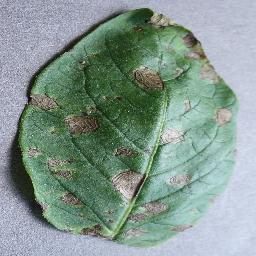

potato_early_blight


In [61]:
sample = datamodule.test_set[1347]
image = sample['image']
crop = sample['crop']
disease = sample['disease']
crop_disease = sample['crop_disease_label']
print(f"CROP: {crop}")
print(f"DISEASE: {disease}")
display(image)
print(crop_disease)

## Inference

In [62]:
def predict_sample(sample, model, transform, idx_label, topk=5):
    image = sample['image']
    # crop_disease = sample['crop_disease_label']

    x = transform(image.convert("RGB")).unsqueeze(0).to(DEVICE)

    with torch.inference_mode():
        logits = model(x)
        probs = nn.functional.softmax(logits, dim=1)[0]
    
    k = min(topk, probs.numel())
    top_probs, top_idxs = torch.topk(probs, k=k)

    top_labels = [idx_label[int(i)] for i in top_idxs]

    return pd.DataFrame({
        "class": top_labels,
        "prob": top_probs.cpu().numpy()
    })

In [63]:
df = predict_sample(sample, model, transform, idx_label, TOPK)

df["prob"] = df["prob"].map(lambda x: f"{x:.6f}")

df

,class,prob
0,potato_early_blight,0.999603
1,potato_late_blight,0.000392
2,tomato_early_blight,0.000003
3,tomato_late_blight,0.000001
4,grape_black_rot,0.000001


# Plot Top-k Distribution

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(range(len(df['prob'])), df['prob'])
plt.xticks(range(len(df['prob'])), df['class'], rotation=75, ha="right")
plt.ylabel("Probability")
plt.title(f"Top-{len(df['prob'])} predictions\n{0}")
plt.tight_layout()
plt.show()